# Prediksi LST dan interpretasi SHAP — acuan skripsi

**Acuan utama: hasil yang dilaporkan dalam Skripsi Deo.** Mode awal `acuan_skripsi`
membaca tabel hasil penelitian tersimpan yang cocok dengan skripsi, lalu membuat
tabel dan visualisasi. Angka tersebut **bukan hasil pelatihan ulang pada sesi ini**.

M4–RF memakai lag LST, NDVI, dan NDBI, dengan estimator terpisah per klaster.
Klaster bukan kolom fitur tambahan. Acuan M4–RF: R² 0,834; RMSE 0,509 °C;
MAE 0,384 °C. Proporsi SHAP: LST 57,34%, NDBI 25,62%, NDVI 17,03%.

Kode pelatihan dan Vector SHAP tambahan tetap tersedia di bagian bawah melalui
mode `hitung_ulang`. Data lokal saat ini belum mereproduksi angka skripsi;
hasil mode tersebut disimpan terpisah dan tidak dipakai menggantikan acuan.
Jalankan **Restart Kernel → Run All** setelah mengganti mode.


In [1]:
# Pilih sumber hasil; nilai acuan tidak ditulis ke hasil estimator.
MODE_ANALISIS = 'acuan_skripsi'  # alternatif: 'hitung_ulang'
if MODE_ANALISIS not in {'acuan_skripsi', 'hitung_ulang'}:
    raise ValueError('MODE_ANALISIS harus acuan_skripsi atau hitung_ulang.')
print('Mode:', MODE_ANALISIS)


Mode: acuan_skripsi


## 📦 Sel 1 — Install Library

In [2]:
import sys
if 'google.colab' in sys.modules:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
                           'geopandas', 'scikit-learn', 'matplotlib', 'seaborn', 'shap', 'joblib', 'openpyxl'])


## 📂 Sel 2 — Mount Google Drive & Path

In [3]:
from pathlib import Path
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/uhi-dashboard/data')
except ImportError:
    BASE_DIR = Path(r'C:/Users/Solideo G. Bangun/uhi-dashboard/data')
PATH_NDVI_NDBI = str(BASE_DIR / 'FINAL_NDVI_NDBI_Grid1km_Jakarta_ALL_YEARS.geojson')
PATH_CLUSTER = str(BASE_DIR / 'cluster_spatial_k4.geojson')
PATH_LST_CSV = str(BASE_DIR / 'LSTPuncakKemarau.geojson')
OUTPUT_DIR = str(BASE_DIR / 'output/regression_reproduction') + os.sep
os.makedirs(OUTPUT_DIR, exist_ok=True)
for path in [PATH_NDVI_NDBI, PATH_CLUSTER, PATH_LST_CSV]:
    if MODE_ANALISIS == 'hitung_ulang' and not Path(path).is_file():
        raise FileNotFoundError(path)
print('Output:', OUTPUT_DIR)


Output: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\regression_reproduction\


## Hasil penelitian sesuai skripsi

Sumber evaluasi utama: `Hasil Evaluasi Cluster.xlsx` (Sheet4), diverifikasi terhadap `evaluasi_model.csv`. Sumber SHAP: `tabel_vector_shap_summary.csv`, dan
`true_vector_shap_cluster_M4_LagAll_byCluster.csv` dalam folder `data`.
Sel pemeriksaan berikut mencocokkan nilai arsip dengan angka skripsi sebelum
grafik dibuat. Tabel keseluruhan dan tabel per klaster dipertahankan sesuai
sumber masing-masing; tidak dianggap sebagai hasil rekonstruksi model terbaru.


In [4]:
if MODE_ANALISIS == 'acuan_skripsi':
    import numpy as np
    import pandas as pd
    import hashlib
    import json
    from IPython.display import display
    ACUAN_OUTPUT = BASE_DIR / 'output/acuan_skripsi'
    ACUAN_OUTPUT.mkdir(parents=True, exist_ok=True)
    # Sheet4 adalah tabel evaluasi yang dikonfirmasi pengguna.
    excel_eval = pd.read_excel(BASE_DIR / 'Hasil Evaluasi Cluster.xlsx', sheet_name='Sheet4')
    excel_eval.columns = excel_eval.columns.astype(str).str.strip()
    excel_eval['Algorithm'] = excel_eval['Algorithm'].astype(str).str.strip()
    excel_eval = excel_eval[excel_eval['Algorithm'].isin(['RF', 'SVR'])].copy()
    evaluation_columns = ['Train_R2','Train_Adj_R2','Test_R2','Test_Adj_R2',
                          'Test_RMSE','Test_MAE','Test_MAPE','CV_R2_Mean','CV_R2_Std']
    evaluasi_acuan = excel_eval[['Config','Algorithm','N_Features','Split'] + evaluation_columns].rename(
        columns={'Config':'konfigurasi','Algorithm':'algoritma','N_Features':'n_fitur',
                 'Split':'split', **{k:k.lower() for k in evaluation_columns}})
    evaluasi_acuan['konfigurasi'] = evaluasi_acuan['konfigurasi'].str.strip()
    evaluasi_acuan.insert(0, 'model', evaluasi_acuan['konfigurasi'].str.split(':').str[0])
    for column in ['n_fitur'] + [k.lower() for k in evaluation_columns]:
        evaluasi_acuan[column] = pd.to_numeric(evaluasi_acuan[column], errors='raise')
    assert len(evaluasi_acuan) == 8 and not evaluasi_acuan.duplicated(['model','algoritma']).any()
    csv_eval = pd.read_csv(BASE_DIR / 'evaluasi_model.csv')
    numeric_columns = [k.lower() for k in evaluation_columns]
    np.testing.assert_allclose(
        evaluasi_acuan.set_index(['model','algoritma']).sort_index()[numeric_columns].to_numpy(dtype=float),
        csv_eval.set_index(['model','algoritma']).sort_index()[numeric_columns].to_numpy(dtype=float),
        atol=1e-10, rtol=0)
    print('Evaluasi Excel Sheet4 cocok dengan arsip evaluasi_model.csv.')
    shap_acuan = pd.read_csv(BASE_DIR / 'tabel_vector_shap_summary.csv')
    klaster_acuan = pd.read_csv(BASE_DIR / 'true_vector_shap_cluster_M4_LagAll_byCluster.csv')
    m4_acuan = evaluasi_acuan.query("model == 'M4' and algoritma == 'RF'").iloc[0]
    np.testing.assert_allclose(m4_acuan[['test_r2','test_rmse','test_mae']].to_numpy(dtype=float),
                               [.834, .509, .384], atol=.0005, rtol=0)
    m4_shap = shap_acuan[shap_acuan['Model'].str.startswith('M4:')].set_index('Variabel')
    np.testing.assert_allclose(m4_shap.loc[['LST','NDBI','NDVI'], 'Kontribusi (%)'],
                               [57.34,25.62,17.03], atol=.005, rtol=0)
    np.testing.assert_allclose(m4_shap.loc[['LST','NDBI','NDVI'], 'Vector SHAP (mean)'],
                               [.64716,.28916,.19223], atol=.000005, rtol=0)
    counts = klaster_acuan.groupby('cluster')['n_samples']
    assert counts.nunique().eq(1).all(), 'Jumlah sampel antarvariabel tidak konsisten.'
    np.testing.assert_array_equal(counts.first().reindex([1,2,3,4]), [26,28,40,34])
    print('Acuan skripsi terverifikasi. Sumber: tabel hasil penelitian tersimpan, bukan pelatihan ulang.')
    display(evaluasi_acuan)
    evaluasi_acuan.to_csv(ACUAN_OUTPUT / 'evaluasi_model_acuan.csv', index=False)
    sources = ['Hasil Evaluasi Cluster.xlsx','evaluasi_model.csv','tabel_vector_shap_summary.csv',
               'true_vector_shap_cluster_M4_LagAll_byCluster.csv']
    provenance = {'mode': MODE_ANALISIS, 'source_type': 'archived_research_tables',
                  'model_refitted': False, 'reproduction_verified': False,
                  'reference_document': 'Skripsi Deo.docx',
                  'evaluation_sheet': 'Sheet4',
                  'sources': {s: hashlib.sha256((BASE_DIR / s).read_bytes()).hexdigest() for s in sources}}
    (ACUAN_OUTPUT / 'sumber_hasil.json').write_text(json.dumps(provenance, indent=2), encoding='utf-8')


Evaluasi Excel Sheet4 cocok dengan arsip evaluasi_model.csv.
Acuan skripsi terverifikasi. Sumber: tabel hasil penelitian tersimpan, bukan pelatihan ulang.


,model,konfigurasi,algoritma,n_fitur,split,train_r2,train_adj_r2,test_r2,test_adj_r2,test_rmse,test_mae,test_mape,cv_r2_mean,cv_r2_std
0,M1,M1: Lag LST saja,RF,5,Semua Grid,0.9757,0.9754,0.7392,0.7285,0.6217,0.4963,0.0128,0.8170,0.0305
1,M1,M1: Lag LST saja,SVR,5,Semua Grid,0.8659,0.8646,0.7566,0.7466,0.6006,0.4663,0.0120,0.8170,0.0401
2,M2,M2: Lag LST (per Cluster),RF,5,Per Cluster,0.9729,0.9726,0.7893,0.7807,0.5735,0.4344,0.0112,0.8028,0.0594
3,M2,M2: Lag LST (per Cluster),SVR,5,Per Cluster,0.8929,0.8918,0.7664,0.7569,0.6039,0.4332,0.0112,0.7995,0.0528
4,M3,M3: Lag LST + NDVI + NDBI,RF,17,Semua Grid,0.9801,0.9794,0.7921,0.7600,0.5550,0.4285,0.0111,0.8431,0.0282
5,M3,M3: Lag LST + NDVI + NDBI,SVR,17,Semua Grid,0.9618,0.9604,0.8250,0.7979,0.5093,0.3749,0.0097,0.8518,0.0312
6,M4,M4: Lag LST + NDVI + NDBI (per Cluster),RF,17,Per Cluster,0.9765,0.9757,0.8340,0.8083,0.5092,0.3840,0.0099,0.8439,0.0389
7,M4,M4: Lag LST + NDVI + NDBI (per Cluster),SVR,17,Per Cluster,0.9768,0.9760,0.8014,0.7707,0.5569,0.3547,0.0092,0.8604,0.0286


In [5]:
if MODE_ANALISIS == 'acuan_skripsi':
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import display
    
    DATA = BASE_DIR
    OUTPUT = BASE_DIR / 'output/acuan_skripsi'
    OUTPUT.mkdir(parents=True, exist_ok=True)
    
    VARIABLES = ['LST', 'NDVI', 'NDBI']
    MODELS = ['M1', 'M2', 'M3', 'M4']
    VARIABLE_COLORS = {'LST': '#d73027', 'NDVI': '#eb6834', 'NDBI': '#1baf7a'}
    CLUSTER_COLORS = {1: '#9EAFE5', 2: '#8FD0B5', 3: '#F7ABAD', 4: '#D0AFE0'}
    plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'figure.facecolor': 'white', 'axes.facecolor': 'white'})
    
    def save_show(fig, name):
        for extension in ['png', 'pdf']:
            fig.savefig(OUTPUT / f'{name}.{extension}', dpi=180, bbox_inches='tight')
        plt.show()
        plt.close(fig)
    
    print('Data:', DATA)
    print('Ekspor:', OUTPUT)


Data: C:\Users\Solideo G. Bangun\uhi-dashboard\data
Ekspor: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\acuan_skripsi


## Sumber data

- `data/tabel_vector_shap_summary.csv`: ringkasan SHAP per variabel yang dilaporkan dalam skripsi untuk M1–M4.
- `data/true_vector_shap_cluster_M4_LagAll_byCluster.csv`: agregasi per variabel dan klaster pada M4–RF.

Jumlah sampel pada file klaster adalah grid yang dipakai untuk ringkasan SHAP,
bukan seluruh anggota klaster. Nilai SHAP disajikan dalam °C.


In [6]:
if MODE_ANALISIS == 'acuan_skripsi':
    summary = pd.read_csv(DATA / 'tabel_vector_shap_summary.csv').rename(columns={
        'Model': 'model', 'Variabel': 'variable', 'Vector SHAP (mean)': 'mean',
        'Vector SHAP (std)': 'std', 'Kontribusi (%)': 'percentage',
        'Jumlah Lag': 'n_lags', 'Lag Terkuat': 'strongest_lag',
        'SHAP Lag Terkuat': 'strongest_lag_shap'})
    summary['code'] = summary['model'].str.split(':').str[0].str.strip()
    clusters = pd.read_csv(DATA / 'true_vector_shap_cluster_M4_LagAll_byCluster.csv').rename(columns={
        'vector_shap_mean': 'mean', 'vector_shap_std': 'std',
        'vector_shap_pct': 'percentage', 'vector_shap_median': 'median',
        'vector_shap_q25': 'q25', 'vector_shap_q75': 'q75'})
    assert not summary.duplicated(['code', 'variable']).any()
    assert not clusters.duplicated(['cluster', 'variable']).any()
    assert set(summary['code']) == set(MODELS)
    assert set(clusters['cluster']) == {1, 2, 3, 4}
    for frame, group in [(summary, 'code'), (clusters, 'cluster')]:
        assert np.isfinite(frame[['mean', 'std', 'percentage']].to_numpy()).all()
        assert (frame[['mean', 'std', 'percentage']] >= 0).all().all()
        np.testing.assert_allclose(frame.groupby(group)['percentage'].sum(), 100, atol=0.05)
    display(summary)
    display(clusters)


,model,variable,n_lags,mean,std,percentage,strongest_lag,strongest_lag_shap,code
0,M1: Lag LST saja,LST,5,1.09034,0.60728,100.00,2012,0.40198,M1
1,M2: Lag LST (per Cluster),LST,5,0.97972,0.55109,100.00,2012,0.33107,M2
2,M3: Lag LST + NDVI + NDBI,LST,5,0.73709,0.53368,59.68,2012,0.29087,M3
3,M3: Lag LST + NDVI + NDBI,NDBI,6,0.28344,0.10851,22.95,2021,0.07407,M3
4,M3: Lag LST + NDVI + NDBI,NDVI,6,0.21460,0.07762,17.37,2012,0.07031,M3
5,M4: Lag LST + NDVI + NDBI (per Cluster),LST,5,0.64716,0.46454,57.34,2012,0.21527,M4
6,M4: Lag LST + NDVI + NDBI (per Cluster),NDBI,6,0.28916,0.13879,25.62,2021,0.06751,M4
7,M4: Lag LST + NDVI + NDBI (per Cluster),NDVI,6,0.19223,0.08218,17.03,2012,0.04904,M4


,cluster,variable,mean,std,vector_shap_sem,q25,q75,median,percentage,n_samples
0,1,LST,0.621241,0.635322,0.124597,0.231395,0.677246,0.377789,63.45,26
1,1,NDVI,0.216613,0.141636,0.027777,0.095642,0.304624,0.220048,22.12,26
2,1,NDBI,0.141210,0.126372,0.024784,0.067141,0.161335,0.099487,14.42,26
3,2,LST,0.336409,0.253313,0.047872,0.157356,0.437054,0.229125,45.12,28
4,2,NDBI,0.276182,0.156169,0.029513,0.160646,0.419656,0.259210,37.04,28
5,2,NDVI,0.133013,0.156900,0.029651,0.018254,0.174361,0.041160,17.84,28
6,3,LST,0.602555,0.738031,0.116693,0.115465,0.755525,0.346300,63.11,40
7,3,NDBI,0.281101,0.156002,0.024666,0.161945,0.371191,0.287138,29.44,40
8,3,NDVI,0.071139,0.069755,0.011029,0.016687,0.092621,0.046888,7.45,40
9,4,LST,0.554818,0.425135,0.072910,0.239298,0.744907,0.464427,62.97,34


## 1. Porsi kontribusi tiap variabel per model

M1/M2 hanya memakai LST; M3/M4 menambahkan NDVI dan NDBI. Warna menunjukkan variabel.

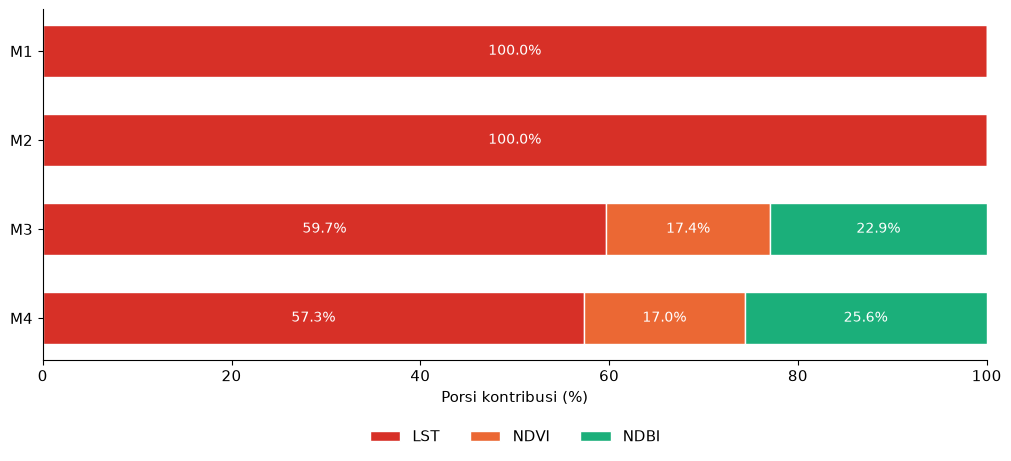

In [7]:
if MODE_ANALISIS == 'acuan_skripsi':
    def composition(frame, group, order, labels, title, filename):
        values = frame.pivot(index=group, columns='variable', values='percentage')
        values = values.reindex(index=order, columns=VARIABLES).fillna(0)
        fig, ax = plt.subplots(figsize=(10, 4.5), layout='constrained')
        positions = np.arange(len(order))
        left = np.zeros(len(order))
        for variable in VARIABLES:
            portions = values[variable].to_numpy()
            ax.barh(positions, portions, left=left, height=.58,
                    color=VARIABLE_COLORS[variable], label=variable, edgecolor='white')
            for i, value in enumerate(portions):
                if value >= 5:
                    ax.text(left[i] + value / 2, i, f'{value:.1f}%',
                            ha='center', va='center', color='white', fontsize=10)
            left += portions
        ax.set(yticks=positions, yticklabels=labels, xlim=(0, 100),
               xlabel='Porsi kontribusi (%)', title=title)
        ax.invert_yaxis()
        ax.legend(loc='upper center', bbox_to_anchor=(.5, -.16), ncol=3, frameon=False)
        save_show(fig, filename)
    
    composition(summary, 'code', MODELS, MODELS,
                '', '01_kontribusi_per_model')


## 2. Besar kontribusi dalam satuan suhu

Rata-rata kontribusi absolut per variabel dari tabel arsip skripsi. Variabel yang tidak digunakan oleh M1/M2 tidak diberi batang.

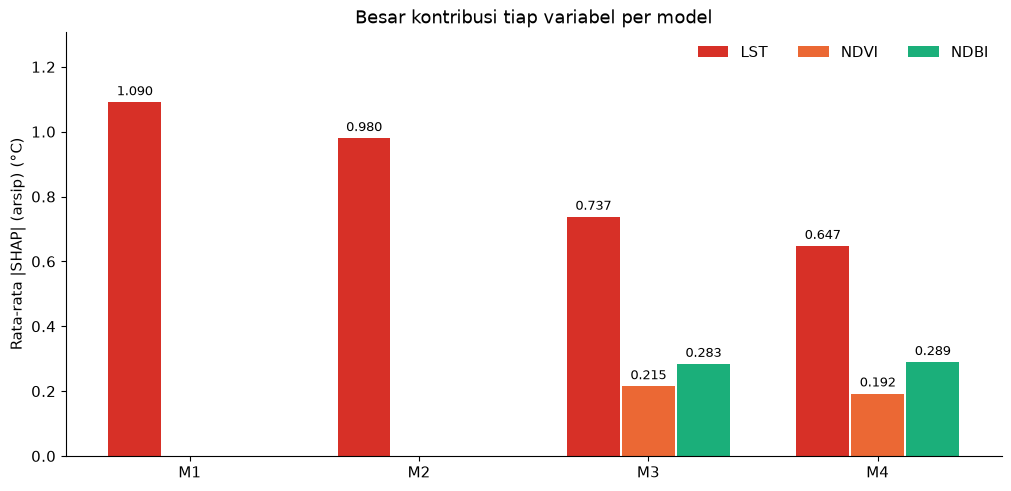

In [8]:
if MODE_ANALISIS == 'acuan_skripsi':
    means = summary.pivot(index='code', columns='variable', values='mean').reindex(index=MODELS, columns=VARIABLES)
    fig, ax = plt.subplots(figsize=(10, 4.8), layout='constrained')
    x = np.arange(len(MODELS))
    for i, variable in enumerate(VARIABLES):
        bars = ax.bar(x + (i - 1) * .24, means[variable], .23,
                      label=variable, color=VARIABLE_COLORS[variable])
        ax.bar_label(bars, labels=[f'{v:.3f}' if pd.notna(v) else '' for v in means[variable]], padding=3, fontsize=9)
    ax.set(xticks=x, xticklabels=MODELS, ylabel='Rata-rata |SHAP| (arsip) (°C)',
           title='Besar kontribusi tiap variabel per model')
    ax.set_ylim(0, float(means.max().max()) * 1.2)
    ax.legend(frameon=False, ncol=3)
    save_show(fig, '02_besar_kontribusi_suhu')


## 3. Ringkasan SHAP: rata-rata, simpangan baku, dan proporsi

Ubah `SELECTED_MODEL` ke M1, M2, M3, atau M4. Garis galat menunjukkan ± satu simpangan baku, bukan arah kontribusi.

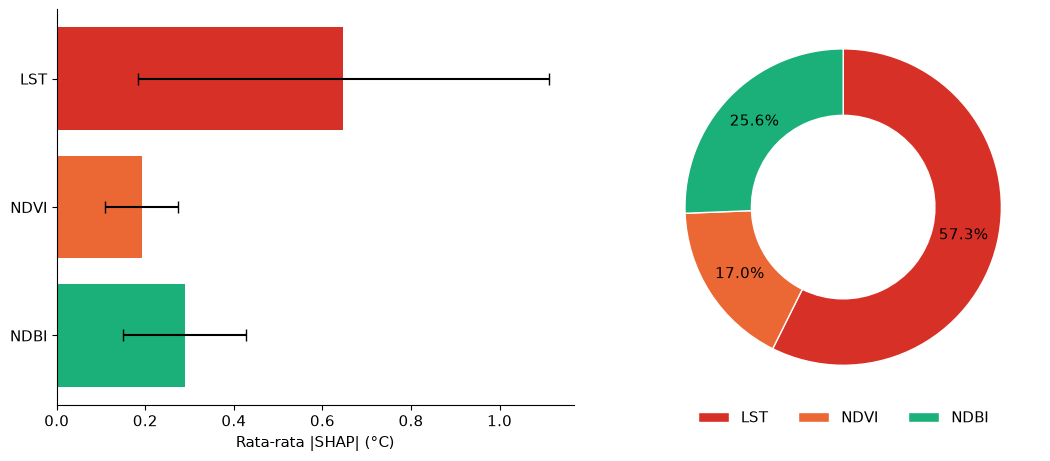

,mean,std,percentage
variable,,,
LST,0.64716,0.46454,57.34
NDVI,0.19223,0.08218,17.03
NDBI,0.28916,0.13879,25.62


In [9]:
if MODE_ANALISIS == 'acuan_skripsi':
    SELECTED_MODEL = 'M4'
    if SELECTED_MODEL not in MODELS:
        raise ValueError('Pilih M1, M2, M3, atau M4.')
    selected = summary[summary['code'].eq(SELECTED_MODEL)].set_index('variable')
    selected = selected.reindex([v for v in VARIABLES if v in selected.index])
    colors = [VARIABLE_COLORS[v] for v in selected.index]
    fig, (ax, pie) = plt.subplots(1, 2, figsize=(11, 4.5), layout='constrained')
    ax.barh(selected.index, selected['mean'], xerr=selected['std'], capsize=4, color=colors)
    ax.invert_yaxis()
    ax.set(title=f'', xlabel='Rata-rata |SHAP| (°C)')
    wedges, _, _ = pie.pie(selected['percentage'], colors=colors, startangle=90,
                           counterclock=False, autopct='%1.1f%%', pctdistance=.78,
                           wedgeprops={'width': .42, 'edgecolor': 'white'})
    pie.set_title(f'')
    pie.legend(wedges, selected.index, loc='upper center', bbox_to_anchor=(.5, .02),
               ncol=len(selected), frameon=False)
    save_show(fig, f'03_ringkasan_{SELECTED_MODEL}_RF')
    display(selected[['mean', 'std', 'percentage']])


## 4. Porsi kontribusi tiap variabel per klaster

Perbandingan Klaster 1–4 untuk **M4–RF**. Warna segmen tetap menunjukkan variabel.

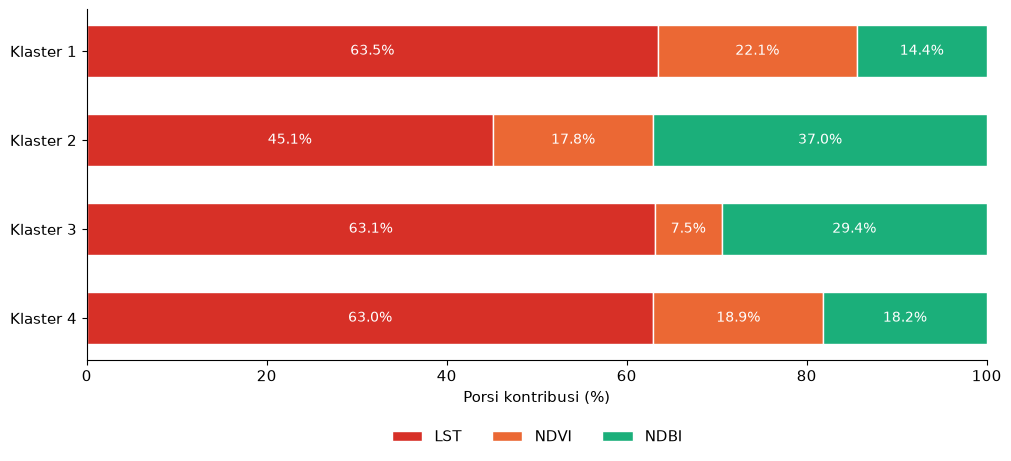

In [10]:
if MODE_ANALISIS == 'acuan_skripsi':
    composition(clusters, 'cluster', [1, 2, 3, 4], [f'Klaster {k}' for k in range(1, 5)],
                '', '04_kontribusi_per_klaster_M4_RF')


## 5. Hasil SHAP masing-masing klaster — M4–RF

Warna panel mengikuti palet klaster pada dashboard: biru, hijau, merah muda, ungu. Skala sumbu sama agar besar kontribusi dapat dibandingkan.

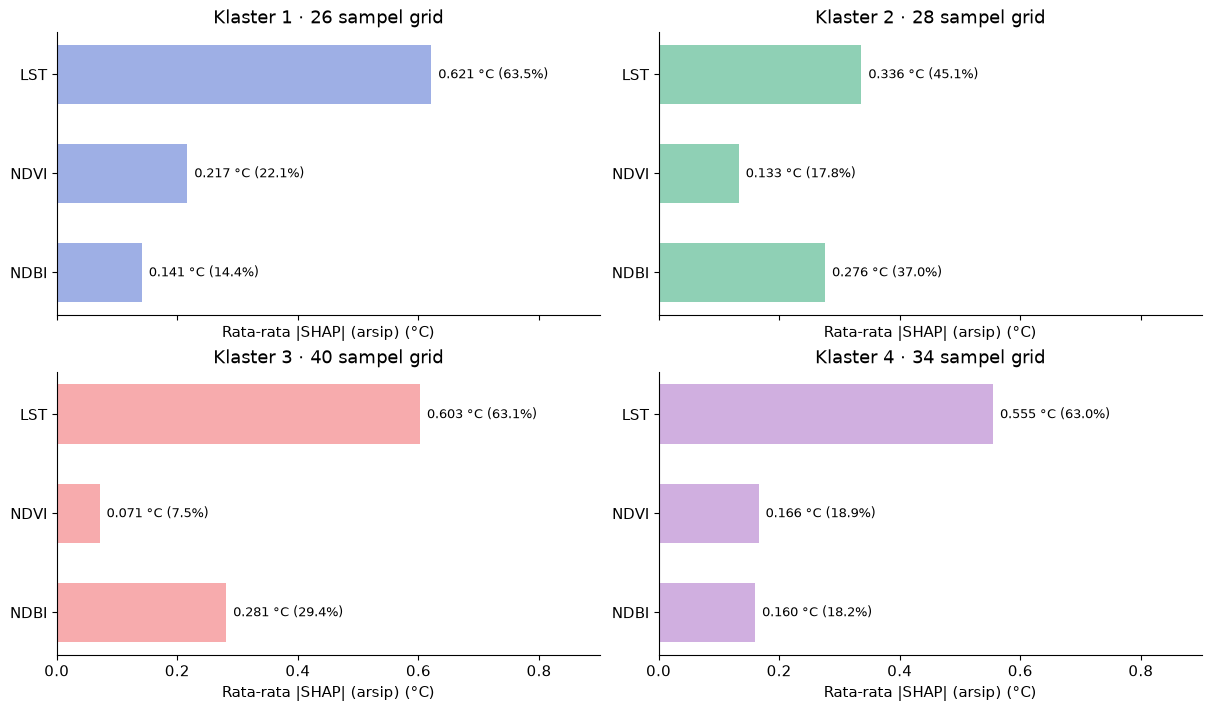

,cluster,variable,mean,std,median,q25,q75,percentage,n_samples
0,1,LST,0.621241,0.635322,0.377789,0.231395,0.677246,63.45,26
1,1,NDVI,0.216613,0.141636,0.220048,0.095642,0.304624,22.12,26
2,1,NDBI,0.141210,0.126372,0.099487,0.067141,0.161335,14.42,26
3,2,LST,0.336409,0.253313,0.229125,0.157356,0.437054,45.12,28
4,2,NDBI,0.276182,0.156169,0.259210,0.160646,0.419656,37.04,28
5,2,NDVI,0.133013,0.156900,0.041160,0.018254,0.174361,17.84,28
6,3,LST,0.602555,0.738031,0.346300,0.115465,0.755525,63.11,40
7,3,NDBI,0.281101,0.156002,0.287138,0.161945,0.371191,29.44,40
8,3,NDVI,0.071139,0.069755,0.046888,0.016687,0.092621,7.45,40
9,4,LST,0.554818,0.425135,0.464427,0.239298,0.744907,62.97,34


Selesai. Semua grafik dan tabel tersedia di: C:\Users\Solideo G. Bangun\uhi-dashboard\data\output\acuan_skripsi


In [11]:
if MODE_ANALISIS == 'acuan_skripsi':
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, layout='constrained')
    limit = float(clusters['mean'].max()) * 1.45
    for k, ax in zip(range(1, 5), axes.flat):
        rows = clusters[clusters['cluster'].eq(k)].set_index('variable').reindex(VARIABLES)
        bars = ax.barh(VARIABLES, rows['mean'], color=CLUSTER_COLORS[k], height=.6)
        ax.bar_label(bars, labels=[f'{r["mean"]:.3f} °C ({r["percentage"]:.1f}%)'
                                  for _, r in rows.iterrows()], padding=5, fontsize=9)
        ax.invert_yaxis()
        ax.set(xlim=(0, limit), xlabel='Rata-rata |SHAP| (arsip) (°C)',
               title=f'Klaster {k} · {int(rows["n_samples"].iloc[0])} sampel grid')
    save_show(fig, '05_shap_masing_masing_klaster_M4_RF')
    table = clusters[['cluster', 'variable', 'mean', 'std', 'median', 'q25', 'q75', 'percentage', 'n_samples']]
    display(table)
    table.to_csv(OUTPUT / 'shap_per_klaster_M4_RF.csv', index=False, encoding='utf-8-sig')
    summary.to_csv(OUTPUT / 'shap_per_model_RF.csv', index=False, encoding='utf-8-sig')
    print('Selesai. Semua grafik dan tabel tersedia di:', OUTPUT)


---
## Perhitungan ulang — belum mereproduksi hasil skripsi

Sel berikut hanya berjalan bila `MODE_ANALISIS = 'hitung_ulang'`. Perhitungan
menggunakan data lokal yang telah dipakai notebook sebelumnya. Hasilnya tidak
boleh diberi label sebagai hasil skripsi sebelum data, anggota split, model,
dan definisi SHAP terbukti sesuai. Keluaran disimpan di `output/regression_reproduction`.

Baseline Vector SHAP tambahan masih menggunakan rata-rata fitur data latih.
Ini adalah pilihan pada implementasi tambahan, bukan klaim reproduksi baseline
eksperimen skripsi. Tabel acuan tidak dimasukkan ke perhitungan model.


## ⚙️ Sel 3 — Import & Konfigurasi

In [12]:
if MODE_ANALISIS == 'hitung_ulang':
    import numpy as np
    import pandas as pd
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from IPython.display import display
    
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.svm import SVR
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split, KFold
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  KONFIGURASI — SESUAIKAN JIKA PERLU
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    LAG_YEARS    = [2009, 2012, 2015, 2018, 2021]   # tahun lag (fitur)
    TARGET_YEAR  = 2024                              # tahun prediksi
    
    NDVI_PREFIX  = 'ndvi'    # prefix kolom NDVI di GeoJSON
    NDBI_PREFIX  = 'ndbi'     # prefix kolom NDBI di GeoJSON (cek screenshot: ndb2009)
    LST_PREFIX   = 'lst'     # prefix kolom LST di CSV
    LST_TARGET_COL = f'lst_{TARGET_YEAR}_EXCLUDED'  # nama kolom LST 2024 di CSV
    
    CLUSTER_RAW  = 'k-means_cluster'   # nama kolom cluster di GeoJSON (ada tanda -)
    CLUSTER_COL  = 'kmeans_cluster'    # nama setelah rename (aman untuk pandas)
    
    TEST_SIZE    = 0.2
    CV_FOLDS     = 5
    SEED         = 42
    
    # Hyperparameter RF
    RF_PARAMS = dict(n_estimators=300, max_features='sqrt',
                     random_state=SEED, n_jobs=-1)
    
    # Hyperparameter SVR
    SVR_PARAMS = dict(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
    
    print('✅ Konfigurasi selesai')
    print(f'   Lag years  : {LAG_YEARS}')
    print(f'   Target     : LST {TARGET_YEAR}')
    print(f'   Test size  : {TEST_SIZE*100:.0f}%   CV folds : {CV_FOLDS}')


## 📥 Sel 4 — Load & Merge Data

In [13]:
if MODE_ANALISIS == 'hitung_ulang':
    # ── (A) Load NDVI / NDBI GeoJSON ──────────────────────────────────────────
    print('Membaca NDVI/NDBI GeoJSON ...')
    gdf_ndvi = gpd.read_file(PATH_NDVI_NDBI)
    # Data lama aktif dashboard berbentuk panjang. Pivot sekali untuk model awal.
    if {'year','NDVI','NDBI'}.issubset(gdf_ndvi.columns):
        gdf_ndvi['year'] = pd.to_numeric(gdf_ndvi['year'],errors='raise').astype(int)
        if gdf_ndvi.duplicated(['grid_id','year']).any():
            raise ValueError('Duplikat indeks grid/tahun.')
        geometry = gdf_ndvi[['grid_id','geometry']].drop_duplicates('grid_id')
        wide = gdf_ndvi.pivot(index='grid_id',columns='year',values=['NDVI','NDBI'])
        wide.columns = [f'{variable.lower()}{year}' for variable,year in wide.columns]
        gdf_ndvi = gpd.GeoDataFrame(geometry.merge(wide.reset_index(),on='grid_id',validate='one_to_one'),
                                   geometry='geometry',crs=gdf_ndvi.crs)
    print(f'  Fitur : {len(gdf_ndvi):,}   Kolom : {list(gdf_ndvi.columns)}')
    
    # ── (B) Load Cluster GeoJSON ──────────────────────────────────────────────
    print('Membaca cluster GeoJSON ...')
    gdf_clust = gpd.read_file(PATH_CLUSTER)
    print(f'  Fitur : {len(gdf_clust):,}   Kolom : {list(gdf_clust.columns)}')
    
    # ── (C) Load LST CSV ──────────────────────────────────────────────────────
    print('Membaca LST CSV ...')
    # Adapter GeoJSON panjang ke format LST lebar yang dipakai notebook awal.
    if Path(PATH_LST_CSV).suffix.lower() == '.csv':
        df_lst = pd.read_csv(PATH_LST_CSV)
    else:
        lst_long = gpd.read_file(PATH_LST_CSV)
        lst_long['period'] = pd.to_numeric(lst_long['period'], errors='raise').astype(int)
        if lst_long.duplicated(['grid_id', 'period']).any():
            raise ValueError('Duplikat grid/periode pada LST.')
        df_lst = lst_long.pivot(index='grid_id', columns='period', values='mean')
        df_lst.columns = [f'lst_{int(year)}' for year in df_lst.columns]
        df_lst = df_lst.reset_index().rename(columns={f'lst_{TARGET_YEAR}': LST_TARGET_COL})
    print(f'  Baris : {len(df_lst):,}   Kolom : {list(df_lst.columns)}')


In [14]:
if MODE_ANALISIS == 'hitung_ulang':
    # ── Standarisasi kolom grid_id ────────────────────────────────────────────
    for obj in [gdf_ndvi, gdf_clust, df_lst]:
        obj['grid_id'] = obj['grid_id'].astype(str).str.strip().str.replace(r'\.0+$', '', regex=True)
    
    # ── Definisi kolom per sumber ─────────────────────────────────────────────
    # LST  : lag tahun sebelum target (prefix pakai underscore → lst_2009)
    lst_cols = [f'{LST_PREFIX}_{y}' for y in LAG_YEARS]
    
    # NDVI/NDBI : lag + tahun target semuanya tersedia di GeoJSON (tanpa underscore → ndvi2009)
    ndvi_ndbi_years = LAG_YEARS + [TARGET_YEAR]                      # [2009,…,2021,2024]
    ndvi_cols       = [f'{NDVI_PREFIX}{y}' for y in ndvi_ndbi_years] # ndvi2009 … ndvi2024
    ndbi_cols       = [f'{NDBI_PREFIX}{y}' for y in ndvi_ndbi_years] # ndbi2009 … ndbi2024
    
    # ── Ambil kolom yang relevan ──────────────────────────────────────────────
    df_ndvi_sel  = gdf_ndvi[['grid_id'] + ndvi_cols + ndbi_cols].copy()
    
    df_clust_sel = gdf_clust[['grid_id', CLUSTER_RAW]].copy()
    df_clust_sel.rename(columns={CLUSTER_RAW: CLUSTER_COL}, inplace=True)
    
    df_lst_sel   = df_lst[['grid_id'] + lst_cols + [LST_TARGET_COL]].copy()
    df_lst_sel.rename(columns={LST_TARGET_COL: f'lst_{TARGET_YEAR}'}, inplace=True)
    
    # ── Merge tiga sumber ─────────────────────────────────────────────────────
    df = (
        df_ndvi_sel
        .merge(df_clust_sel, on='grid_id', how='inner')
        .merge(df_lst_sel,   on='grid_id', how='inner')
    )
    
    # ── Konversi numerik ──────────────────────────────────────────────────────
    num_cols = ndvi_cols + ndbi_cols + lst_cols + [f'lst_{TARGET_YEAR}', CLUSTER_COL]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    
    df.to_csv(OUTPUT_DIR + 'merged_before_dropna.csv', index=False)
    df = df.dropna().reset_index(drop=True)
    assert f'ndvi{TARGET_YEAR}' in df and f'ndbi{TARGET_YEAR}' in df
    df.to_csv(OUTPUT_DIR + 'analysis_data.csv', index=False)
    
    print(f'\n✅ Merge selesai: {len(df):,} grid dengan data lengkap')
    print(f'   LST lag years    : {LAG_YEARS}')
    print(f'   NDVI/NDBI years  : {ndvi_ndbi_years}')
    print(f'\n   Cluster distribution:')
    print(df[CLUSTER_COL].value_counts().sort_index().to_string())
    display(df.head())


## 🔍 Sel 5 — Eksplorasi Data (EDA)

In [15]:
if MODE_ANALISIS == 'hitung_ulang':
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Distribusi target
    axes[0].hist(df[f'lst_{TARGET_YEAR}'], bins=30, color='#E63946', edgecolor='white')
    axes[0].set_title(f'Distribusi LST {TARGET_YEAR}', fontweight='bold')
    axes[0].set_xlabel('LST (°C)')
    axes[0].set_ylabel('Frekuensi')
    
    # Distribusi cluster
    vc = df[CLUSTER_COL].value_counts().sort_index()
    axes[1].bar(vc.index.astype(str), vc.values, color='#2A9D8F', edgecolor='white')
    axes[1].set_title('Jumlah Grid per Cluster', fontweight='bold')
    axes[1].set_xlabel('Cluster (K-Means)')
    axes[1].set_ylabel('Jumlah Grid')
    for i, v in enumerate(vc.values):
        axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)
    
    # Boxplot LST 2024 per cluster
    df.boxplot(column=f'lst_{TARGET_YEAR}', by=CLUSTER_COL, ax=axes[2],
               patch_artist=True)
    axes[2].set_title(f'LST {TARGET_YEAR} per Cluster', fontweight='bold')
    axes[2].set_xlabel('Cluster (K-Means)')
    axes[2].set_ylabel('LST (°C)')
    plt.suptitle('')
    
    sns.despine()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'eda_distribusi.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('\nStatistik Deskriptif (target + lag LST):')
    display(df[[f'lst_{TARGET_YEAR}'] + lst_cols].describe().round(3))


## 🔧 Sel 6 — Definisi Fitur & Fungsi Helper

In [16]:
if MODE_ANALISIS == 'hitung_ulang':
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  DEFINISI FITUR UNTUK 4 KONFIGURASI MODEL
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    
    TARGET_COL = f'lst_{TARGET_YEAR}'
    
    MODEL_CONFIGS = {
        'M1_LagLST': {
            'label'           : 'M1: Lag LST saja',
            'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]}',
            'features'        : lst_cols,
            'split_by_cluster': False,
        },
        'M2_LagLST_byCluster': {
            'label'           : 'M2: Lag LST (per Cluster)',
            'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]}, model dilatih per cluster',
            'features'        : lst_cols,
            'split_by_cluster': True,
        },
        'M3_LagAll': {
            'label'           : 'M3: Lag LST + NDVI + NDBI',
            'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]} + ndvi/ndbi {ndvi_ndbi_years[0]}–{ndvi_ndbi_years[-1]}',
            'features'        : lst_cols + ndvi_cols + ndbi_cols,
            'split_by_cluster': False,
        },
        'M4_LagAll_byCluster': {
            'label'           : 'M4: Lag LST + NDVI + NDBI (per Cluster)',
            'desc'            : f'lst {LAG_YEARS[0]}–{LAG_YEARS[-1]} + ndvi/ndbi {ndvi_ndbi_years[0]}–{ndvi_ndbi_years[-1]}, per cluster',
            'features'        : lst_cols + ndvi_cols + ndbi_cols,
            'split_by_cluster': True,
        },
    }
    
    print('✅ Konfigurasi model:')
    print(f'   lst_cols  ({len(lst_cols)}): {lst_cols}')
    print(f'   ndvi_cols ({len(ndvi_cols)}): {ndvi_cols}')
    print(f'   ndbi_cols ({len(ndbi_cols)}): {ndbi_cols}')
    print()
    for key, cfg in MODEL_CONFIGS.items():
        split_info = f'split per {CLUSTER_COL}' if cfg['split_by_cluster'] else 'semua data'
        print(f'   {cfg["label"]}')
        print(f'      Fitur ({len(cfg["features"])}): {cfg["desc"]}')
        print(f'      Data : {split_info}')


In [17]:
if MODE_ANALISIS == 'hitung_ulang':
    def build_estimator(algorithm):
        if algorithm == 'RF':
            return RandomForestRegressor(**RF_PARAMS)
        return Pipeline([('scaler', StandardScaler()), ('svr', SVR(**SVR_PARAMS))])
    
    
    def calculate_metrics(actual, predicted, n_features, prefix=''):
        actual, predicted = np.asarray(actual), np.asarray(predicted)
        score = r2_score(actual, predicted)
        n = len(actual)
        nonzero = actual != 0
        values = dict(R2=score,
            Adj_R2=1-(1-score)*(n-1)/(n-n_features-1) if n>n_features+1 else np.nan,
            RMSE=np.sqrt(mean_squared_error(actual,predicted)),
            MAE=mean_absolute_error(actual,predicted),
            MAPE=np.mean(np.abs((actual[nonzero]-predicted[nonzero])/actual[nonzero]))*100 if nonzero.any() else np.nan)
        return {prefix+name:float(value) for name,value in values.items()}
    
    
    def fit_models(features, algorithm, train_indices, per_cluster):
        fitted = {}
        labels = sorted(df.loc[train_indices,CLUSTER_COL].unique()) if per_cluster else ['global']
        for label in labels:
            # Urutan latih per klaster mengikuti notebook awal (urutan baris df).
            members = np.sort(train_indices[df.loc[train_indices,CLUSTER_COL].to_numpy()==label]) if per_cluster else train_indices
            estimator = build_estimator(algorithm)
            estimator.fit(df.loc[members,features].values,df.loc[members,TARGET_COL].values)
            fitted[label] = estimator
        return fitted
    
    
    def predict_models(fitted, features, indices, per_cluster):
        predicted = np.full(len(indices),np.nan)
        labels = df.loc[indices,CLUSTER_COL].to_numpy()
        for label, estimator in fitted.items():
            mask = labels==label if per_cluster else np.ones(len(indices),dtype=bool)
            if mask.any():
                predicted[mask] = estimator.predict(df.loc[indices[mask],features].values)
        if not np.isfinite(predicted).all():
            raise ValueError('Ada grid tanpa prediksi/model klaster.')
        return predicted
    
    
    def evaluate_model(config, algorithm, train_indices, test_indices, folds):
        features, per_cluster = config['features'],config['split_by_cluster']
        cv_scores = []
        for a,b in folds:
            tr,va = train_indices[a],train_indices[b]
            fitted_fold = fit_models(features,algorithm,tr,per_cluster)
            predicted_fold = predict_models(fitted_fold,features,va,per_cluster)
            cv_scores.append(r2_score(df.loc[va,TARGET_COL],predicted_fold))
        fitted = fit_models(features,algorithm,train_indices,per_cluster)
        train_prediction = predict_models(fitted,features,train_indices,per_cluster)
        test_prediction = predict_models(fitted,features,test_indices,per_cluster)
        scores = calculate_metrics(df.loc[train_indices,TARGET_COL],train_prediction,len(features),'Train_')
        scores.update(calculate_metrics(df.loc[test_indices,TARGET_COL],test_prediction,len(features),'Test_'))
        scores.update(CV_R2_Mean=float(np.mean(cv_scores)),CV_R2_Std=float(np.std(cv_scores)))
        result = dict(**scores,features=features,models=fitted,
                      y_test=df.loc[test_indices,TARGET_COL].values,y_pred_test=test_prediction,
                      y_train=df.loc[train_indices,TARGET_COL].values,y_pred_train=train_prediction,
                      X_test=df.loc[test_indices,features].values,X_train=df.loc[train_indices,features].values)
        if per_cluster:
            result['idx_test_union'] = test_indices.copy()
            result['cluster_models'] = {cl:{algorithm:estimator} for cl,estimator in fitted.items()}
            result['cluster_X_train'] = {cl:df.loc[train_indices[df.loc[train_indices,CLUSTER_COL].to_numpy()==cl],features].values for cl in fitted}
            # model_obj tidak dipakai sebagai proxy model global.
        else:
            result['model_obj'] = fitted['global']
        return result


## 🚀 Sel 7 — Training Semua Model (RF + SVR × 4 Konfigurasi)

In [18]:
if MODE_ANALISIS == 'hitung_ulang':
    idx_train_global,idx_test_global = train_test_split(
        np.arange(len(df)),test_size=TEST_SIZE,random_state=SEED)
    folds = list(KFold(n_splits=CV_FOLDS,shuffle=True,random_state=SEED).split(idx_train_global))
    clusters = sorted(df[CLUSTER_COL].unique())
    all_results,summary_rows = {},[]
    for config_key,config in MODEL_CONFIGS.items():
        for algorithm in ['RF','SVR']:
            print('Melatih:',config_key,algorithm,flush=True)
            result = evaluate_model(config,algorithm,idx_train_global,idx_test_global,folds)
            all_results[(config_key,algorithm)] = result
            summary_rows.append(dict(Config=config['label'],Algorithm=algorithm,
                N_Features=len(config['features']),Split='Per Cluster' if config['split_by_cluster'] else 'Semua Grid',
                **{name:result[name] for name in result if name.startswith(('Train_','Test_','CV_'))}))
    df_summary = pd.DataFrame(summary_rows)
    print('Delapan model selesai. CV memakai grid latih saja.')


In [19]:
if MODE_ANALISIS == 'hitung_ulang':
    """Sel ekspor notebook awal: dieksekusi setelah seluruh delapan model selesai.
    
    Kode ini juga disalin ke notebook agar notebook tetap mandiri di Colab.
    """
    import hashlib
    import json
    from datetime import datetime, timezone
    from pathlib import Path
    import joblib
    
    # Gunakan M4?RF sebagai model utama penelitian; evaluasi tetap apa adanya.
    ranking = []
    test_export = df.iloc[idx_test_global][['grid_id', TARGET_COL, CLUSTER_COL]].copy()
    test_export = test_export.rename(columns={CLUSTER_COL: 'Cluster'}).set_index('grid_id')
    for (key, algorithm), result in all_results.items():
        config = MODEL_CONFIGS[key]
        test_idx = np.asarray(result['idx_test_union'] if config['split_by_cluster'] else idx_test_global)
        ids = df.iloc[test_idx]['grid_id'].to_numpy()
        if set(ids) != set(test_export.index) or len(ids) != len(set(ids)):
            raise ValueError('Keanggotaan grid uji antar model tidak identik.')
        aligned = pd.Series(result['y_pred_test'], index=ids)
        column = f'pred_{key}_{algorithm}'
        test_export[column] = aligned.reindex(test_export.index)
        score = r2_score(test_export[TARGET_COL], test_export[column])
        rmse = np.sqrt(mean_squared_error(test_export[TARGET_COL], test_export[column]))
        ranking.append(dict(key=key, algorithm=algorithm, r2=float(score), rmse=float(rmse)))
        if abs(score-result['Test_R2']) > 0.000051:
            raise ValueError('Metrik prediksi tersimpan tidak sesuai hasil model.')
    best = next(row for row in ranking if row['key'] == 'M4_LagAll_byCluster' and row['algorithm'] == 'RF')
    best_key, best_algorithm = best['key'], best['algorithm']
    best_config = MODEL_CONFIGS[best_key]
    best_result = all_results[(best_key, best_algorithm)]
    all_prediction = np.full(len(df), np.nan)
    if best_config['split_by_cluster']:
        fitted_models = {}
        for cluster in sorted(df[CLUSTER_COL].unique()):
            members = df.index[df[CLUSTER_COL].eq(cluster)].to_numpy()
            estimator = best_result['cluster_models'][cluster][best_algorithm]
            all_prediction[members] = estimator.predict(df.loc[members, best_config['features']].values)
            fitted_models[str(int(cluster))] = estimator
    else:
        fitted_models = {'global': best_result['model_obj']}
        all_prediction = best_result['model_obj'].predict(df[best_config['features']].values)
    if not np.isfinite(all_prediction).all():
        raise ValueError('Prediksi model terbaik tidak lengkap.')
    best_predictions = df[['grid_id', CLUSTER_COL, TARGET_COL]].rename(
        columns={CLUSTER_COL:'cluster', TARGET_COL:'aktual'}).copy()
    best_predictions['prediksi'] = all_prediction
    best_predictions['selisih'] = best_predictions['prediksi']-best_predictions['aktual']
    best_predictions['split'] = np.where(df.index.isin(idx_test_global), 'test', 'train')
    best_predictions['model'] = best_key.split('_')[0]
    best_predictions['algoritma'] = best_algorithm
    test_best = best_predictions[best_predictions['split'].eq('test')]
    np.testing.assert_allclose(r2_score(test_best['aktual'],test_best['prediksi']),best['r2'],atol=1e-10)
    test_export.reset_index().to_csv(OUTPUT_DIR+'all_predictions_test_set.csv',index=False)
    best_predictions.to_csv(OUTPUT_DIR+'best_model_predictions.csv',index=False)
    df_summary.to_csv(OUTPUT_DIR+'summary_evaluation.csv',index=False)
    joblib.dump(dict(models=fitted_models,features=best_config['features'],
                     split_by_cluster=best_config['split_by_cluster']),OUTPUT_DIR+'best_model.joblib')
    
    manifest = dict(created_utc=datetime.now(timezone.utc).isoformat(),
        source='legacy_pre_harmonization', selection='research_model_m4_rf',
        selection_label='M4-RF ditetapkan sebagai model utama penelitian',
        best_model=best_key.split('_')[0],best_config=best_key,best_algorithm=best_algorithm,
        best_label=best_config['label'],n_features=len(best_config['features']),
        test_r2=best['r2'],test_rmse=best['rmse'],
        test_mae=float(mean_absolute_error(test_best['aktual'],test_best['prediksi'])),
        n_train=len(idx_train_global),n_test=len(idx_test_global),n_complete=len(df),
        ndvi_ndbi_years=ndvi_ndbi_years,seed=SEED,
        residual_definition='prediction_minus_actual',
        inputs={str(Path(p).resolve()):hashlib.sha256(Path(p).read_bytes()).hexdigest()
                for p in [PATH_NDVI_NDBI,PATH_CLUSTER,PATH_LST_CSV]})
    Path(OUTPUT_DIR+'best_model.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8')
    print('MODEL TERBAIK DATA LAMA:',manifest['best_model'],best_algorithm,
          '| R2 uji:',best['r2'],'| RMSE uji:',best['rmse'])
    display(best_predictions.head())
    
    # Peta holdout: tidak menggabungkan galat latih ke dalam evaluasi data uji.
    spatial = gdf_ndvi[['grid_id','geometry']].merge(best_predictions,on='grid_id',validate='one_to_one')
    spatial = gpd.GeoDataFrame(spatial,geometry='geometry',crs=gdf_ndvi.crs)
    spatial.to_file(OUTPUT_DIR+'best_model_predictions.geojson',driver='GeoJSON')
    test_map = spatial[spatial['split'].eq('test')]
    fig, axes = plt.subplots(1,3,figsize=(16,6))
    lower = min(test_map['aktual'].min(),test_map['prediksi'].min())
    upper = max(test_map['aktual'].max(),test_map['prediksi'].max())
    limit = max(float(test_map['selisih'].abs().max()),.01)
    for ax,column,title in zip(axes,['aktual','prediksi','selisih'],
                               ['LST aktual','LST prediksi','Prediksi − aktual']):
        kwargs = dict(cmap='RdBu_r',vmin=-limit,vmax=limit) if column=='selisih' else dict(cmap='YlOrRd',vmin=lower,vmax=upper)
        test_map.plot(column=column,ax=ax,legend=True,**kwargs)
        ax.set_title(f'{title} (°C) — {manifest["best_model"]} {best_algorithm}')
        ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR+'peta_model_terbaik_holdout.png',dpi=160)
    plt.show()
    plt.close(fig)


## 📋 Sel 8 — Tabel Hasil Evaluasi

In [20]:
if MODE_ANALISIS == 'hitung_ulang':
    display(df_summary.round(4))
    print('Model terbaik:', manifest['best_model'],manifest['best_algorithm'])
    print('Kriteria:',manifest['selection_label'])
    print('Grid latih:',manifest['n_train'],'| Grid uji:',manifest['n_test'])
    print('Output:',OUTPUT_DIR)


## 📊 Sel 9 — Plot Perbandingan Metrik

In [21]:
if MODE_ANALISIS == 'hitung_ulang':
    metrics     = ['Test_R2', 'Test_Adj_R2', 'Test_RMSE', 'Test_MAE', 'Test_MAPE', 'CV_R2_Mean']
    m_titles    = ['Test R²', 'Test Adj R²', 'Test RMSE', 'Test MAE', 'Test MAPE (%)', 'CV R² Mean']
    algos       = ['RF', 'SVR']
    configs     = [cfg['label'] for cfg in MODEL_CONFIGS.values()]
    x           = np.arange(len(configs))
    width       = 0.35
    algo_colors = ['#2A9D8F', '#E63946']
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f'Perbandingan Performa Model — Prediksi LST {TARGET_YEAR}',
                 fontsize=14, fontweight='bold')
    
    for ax, metric, title in zip(axes.flatten(), metrics, m_titles):
        for i, algo in enumerate(algos):
            vals = df_summary[df_summary['Algorithm'] == algo][metric].values
            bars = ax.bar(x + i * width - width/2, vals, width,
                          label=algo, color=algo_colors[i], alpha=0.85,
                          edgecolor='white')
            fmt = '%.2f%%' if metric == 'Test_MAPE' else '%.3f'
            ax.bar_label(bars, fmt=fmt, fontsize=7.5, padding=1)
    
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([c.split(':')[0] for c in configs], fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'plot_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Disimpan: {OUTPUT_DIR}plot_metrics_comparison.png')


## 🎯 Sel 10 — Plot Prediksi vs Aktual (Scatter)

In [22]:
if MODE_ANALISIS == 'hitung_ulang':
    cfg_keys = list(MODEL_CONFIGS.keys())
    n_cfg    = len(cfg_keys)
    n_algo   = 2  # RF, SVR
    
    fig, axes = plt.subplots(n_algo, n_cfg, figsize=(5.5 * n_cfg, 5.5 * n_algo))
    fig.suptitle(f'Prediksi vs Aktual LST {TARGET_YEAR}',
                 fontsize=14, fontweight='bold')
    
    palette_scatter = ['#2A9D8F', '#E63946']
    
    for row_i, algo in enumerate(['RF', 'SVR']):
        for col_i, cfg_key in enumerate(cfg_keys):
            ax   = axes[row_i][col_i]
            res  = all_results[(cfg_key, algo)]
            y_t  = res['y_test']
            y_p  = res['y_pred_test']
            r2   = res['Test_R2']
            rmse = res['Test_RMSE']
    
            ax.scatter(y_t, y_p, alpha=0.5, s=18,
                       color=palette_scatter[row_i], edgecolors='none')
    
            # Garis perfect prediction
            lims = [min(y_t.min(), y_p.min()) - 0.5,
                    max(y_t.max(), y_p.max()) + 0.5]
            ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.7)
    
            ax.set_title(f'{MODEL_CONFIGS[cfg_key]["label"]}\n{algo}',
                         fontsize=9, fontweight='bold')
            ax.set_xlabel('LST Aktual (°C)', fontsize=8)
            ax.set_ylabel('LST Prediksi (°C)', fontsize=8)
            ax.text(0.05, 0.92, f'R²={r2:.3f}\nRMSE={rmse:.3f}',
                    transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3, linestyle='--')
            sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'plot_scatter_pred_vs_actual.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Disimpan: {OUTPUT_DIR}plot_scatter_pred_vs_actual.png')


## 🌲 Sel 11 — Feature Importance (Random Forest)

In [23]:
if MODE_ANALISIS == 'hitung_ulang':
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Feature Importance — Random Forest',
                 fontsize=14, fontweight='bold')
    
    colors_fi = plt.cm.viridis
    
    for ax, cfg_key in zip(axes.flatten(), cfg_keys):
        res      = all_results[(cfg_key, 'RF')]
        feats    = res['features']
        if MODEL_CONFIGS[cfg_key]['split_by_cluster']:
            weights = [len(res['cluster_X_train'][cl]) for cl in clusters]
            imps = np.average([res['cluster_models'][cl]['RF'].feature_importances_ for cl in clusters], axis=0, weights=weights)
        else:
            imps = res['models']['global'].feature_importances_
    
        # Sort descending
        sorted_idx = np.argsort(imps)[::-1]
        top_n      = min(15, len(feats))
        top_idx    = sorted_idx[:top_n]
    
        top_feats = [feats[i] for i in top_idx]
        top_imps  = imps[top_idx]
    
        bar_colors = [colors_fi(v / top_imps.max()) for v in top_imps]
        bars = ax.barh(range(top_n), top_imps[::-1], color=bar_colors[::-1])
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_feats[::-1], fontsize=8)
        ax.set_title(f'{MODEL_CONFIGS[cfg_key]["label"]}\n'
                     f'Test R²={res["Test_R2"]:.4f}',
                     fontsize=9.5, fontweight='bold')
        ax.set_xlabel('Importance', fontsize=9)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'plot_feature_importance_rf.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Disimpan: {OUTPUT_DIR}plot_feature_importance_rf.png')


## Sel 12 — Vector SHAP per variabel dan klaster

Adaptasi kode lampiran untuk hasil RF M1–M4 pada notebook ini. Jalankan sel sebelumnya terlebih dahulu. M4–RF tetap menjadi model utama; setiap grid dijelaskan memakai estimator klasternya sendiri.

Seluruh tahun suatu variabel menjadi satu kelompok. Baseline memakai **rata-rata fitur data latih** model terkait, bukan data uji. Ringkasan keseluruhan menggabungkan kontribusi semua grid uji (berbobot jumlah grid), dengan baseline berbeda untuk setiap model klaster. SHAP standar menggunakan baseline yang sama untuk perbandingan.

Batang menampilkan rata-rata kontribusi absolut (°C), garis Q25–Q75, dan tanda median. IQR merupakan sebaran kontribusi, bukan interval kepercayaan. Nilai absolut tidak menunjukkan arah pengaruh atau hubungan sebab-akibat. NDVI/NDBI 2024 adalah fitur tahun target, bukan lag sebelum 2024.

Referensi Choi et al. (2025) mengikuti lampiran pengguna. Pemeriksaan numerik di sini menguji rekonstruksi prediksi, bukan membuktikan kesesuaian seluruh implementasi dengan artikel. Hasil baru disimpan dalam subfolder `vector_shap` dari `OUTPUT_DIR`.


In [24]:
if MODE_ANALISIS == 'hitung_ulang':
    import re
    import itertools
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import seaborn as sns
    from scipy.special import comb
    
    
    
    # ─────────────────────────────────────────────────────────────────────────────
    # UTILITAS
    # ─────────────────────────────────────────────────────────────────────────────
    
    def extract_year(feat_name: str):
        m = re.search(r'(19|20)\d{2}', feat_name)
        return int(m.group()) if m else None
    
    def get_var_type(feat_name: str) -> str:
        fn = feat_name.upper().replace('_', '').replace('-', '')
        for vtype in ['NDBI', 'NDVI', 'LST']:
            if fn.startswith(vtype):
                return vtype
        return 'LAINNYA'
    
    COLOR_VAR = {'LST': '#d73027', 'NDVI': '#eb6834',
                 'NDBI': '#1baf7a', 'LAINNYA': '#9e9e9e'}
    
    CLUSTER_PALETTE = ['#9EAFE5', '#8FD0B5', '#F7ABAD', '#D0AFE0',
                       '#f57c00', '#0277bd']
    
    
    # ═════════════════════════════════════════════════════════════════════════════
    # FUNGSI INTI: TRUE VECTOR KERNEL SHAP
    # Implementasi Persamaan (4)-(8) dari Choi et al. (2025)
    # ═════════════════════════════════════════════════════════════════════════════
    
    def _shap_kernel_weight(z: np.ndarray, J: int) -> float:
        """
        Kernel weight w(z) dari persamaan (6) jurnal Choi et al. (2025):
            w(z) = (J-1) / [C(J, |z|) * |z| * (J - |z|)]
        Di mana |z| adalah jumlah elemen 1 dalam z.
        Untuk |z|=0 atau |z|=J, w(z)=∞ (constraint penuh).
        """
        s = int(z.sum())
        if s == 0 or s == J:
            return np.inf
        return (J - 1) / (comb(J, s, exact=True) * s * (J - s))
    
    
    def compute_true_vector_shap(
            model,
            X_test: np.ndarray,
            feature_names: list,
            var_groups: dict,
            background: np.ndarray = None) -> dict:
        """
        Implementasi Vector Kernel SHAP sesuai Choi et al. (2025),
        Persamaan (4)-(8).
    
        Ide utama (dari jurnal, hal. 636-637):
        - Perlakukan setiap variabel (LST, NDVI, NDBI) sebagai SATU pemain
        - z ∈ {0,1}^J: vektor biner sepanjang jumlah variabel J
        - zⱼ=1: gunakan nilai aktual Xⱼ
        - zⱼ=0: ganti seluruh lag Xⱼ dengan nilai mean (imputasi)
        - Jalankan Kernel SHAP di ruang J dimensi (bukan M dimensi)
    
        Parameter
        ---------
        model         : model terlatih dengan method .predict()
        X_test        : np.ndarray (n_samples, n_features)
        feature_names : list nama fitur
        var_groups    : dict {nama_variabel: [indeks_kolom]}
                        misal {'LST': [0,1,2,3,4], 'NDVI': [5,6,7,8,9,10]}
        background    : np.ndarray (n_bg, n_features), default=mean X_test
    
        Returns
        -------
        dict: {
            'phi'     : np.ndarray (n_samples, J) — Vector SHAP values Φⱼ
            'phi0'    : np.ndarray (n_samples,)   — baseline predictions
            'var_names': list nama variabel [J]
            'local_accuracy_check': float — max |Σ Φⱼ - (ŷ - ŷ_baseline)|
        }
        """
        var_names = list(var_groups.keys())
        J = len(var_names)
        n_samples = X_test.shape[0]
    
        # Background: mean setiap fitur (imputasi untuk zⱼ=0)
        # Sesuai jurnal: x̄ⱼ = mean sample dari lag variabel j [hal. 635]
        if background is None:
            background = X_test.mean(axis=0, keepdims=True)  # (1, M)
        X_mean = background.mean(axis=0)  # (M,) — mean per fitur
    
        # Prediksi baseline: f(X̄₁, X̄₂, ..., X̄ⱼ) = f(background)
        # Sesuai jurnal persamaan (7): f₀ = f(h(0)) = Φ₀
        phi0 = model.predict(
            np.tile(X_mean, (n_samples, 1))
        ).flatten()  # (n_samples,)
    
        # Prediksi aktual: f(X₁, X₂, ..., Xⱼ) = ŷ
        y_pred = model.predict(X_test).flatten()  # (n_samples,)
    
        # ── Kasus khusus J=1: hanya satu variabel ─────────────────────────────
        # Jika J=1 (misal model M2 yang hanya pakai LST), tidak ada koalisi
        # parsial yang mungkin (z_valid = {} karena 0 < sum(z) < 1 mustahil).
        # Dalam kasus ini Φ₁ = ŷ - Φ₀ secara langsung dari local accuracy:
        #   Φ₀ + Φ₁ = ŷ  →  Φ₁ = ŷ - Φ₀
        # Ini adalah solusi analitik eksak untuk J=1.
        if J == 1:
            PHI = (y_pred - phi0).reshape(n_samples, 1)
            local_acc_error = float(np.abs(phi0 + PHI[:, 0] - y_pred).max())
            return {
                'phi'                  : PHI,
                'phi0'                 : phi0,
                'var_names'            : var_names,
                'y_pred'               : y_pred,
                'local_accuracy_error' : local_acc_error,
            }
    
        # ── J >= 2: Kernel SHAP di level variabel ─────────────────────────────
        # Enumerate semua z ∈ {0,1}^J kecuali 0 dan 1
        # Sesuai jurnal: WLS dijalankan untuk z ∈ {0,1}^J - {0, 1}
        all_z   = list(itertools.product([0, 1], repeat=J))
        z_valid = [z for z in all_z if 0 < sum(z) < J]
        n_z     = len(z_valid)  # = 2^J - 2
    
        # ── Hitung fz untuk setiap z dan setiap sampel ────────────────────────
        # fz = f(h(z)): prediksi saat variabel dengan zⱼ=0 diganti mean
        # Sesuai jurnal persamaan (4)-(5)
        F_z = np.zeros((n_samples, n_z))  # (n_samples, 2^J - 2)
    
        for iz, z in enumerate(z_valid):
            X_hz = X_test.copy()
            for j, var_name in enumerate(var_names):
                if z[j] == 0:
                    # Ganti semua lag variabel j dengan nilai mean-nya
                    # Sesuai jurnal persamaan (4): X̃ⱼ = X̄ⱼ jika zⱼ=0
                    col_idxs = var_groups[var_name]
                    X_hz[:, col_idxs] = X_mean[col_idxs]
            F_z[:, iz] = model.predict(X_hz).flatten()
    
        # ── Kernel SHAP via WLS ────────────────────────────────────────────────
        # Sesuai jurnal persamaan (6)-(9):
        # Fit: fz = Φ₀ + Φ₁z₁ + ... + ΦⱼzJ + ez
        # Subject to: Φ₀ = f₀, Φ₀ + ΣΦⱼ = ŷ
        # Solution: Φ = A⁻¹(b - 1·(1ᵀA⁻¹b - f1 + f0)/(1ᵀA⁻¹1))
    
        # Matriks Z (n_z, J) dan bobot w (n_z,)
        Z = np.array(z_valid, dtype=float)
        w = np.array([_shap_kernel_weight(np.array(z), J) for z in z_valid])
    
        # A = Σ_{z} z zᵀ w(z) / (2^J - 2)   shape: (J, J)
        # Gunakan (Z * w[:,None]).T @ Z agar selalu menghasilkan array 2D
        Zw  = Z * w[:, np.newaxis]          # (n_z, J)
        A   = (Zw.T @ Z) / n_z             # (J, J)  ← selalu 2D jika J>=2
    
        # Invers A — gunakan pinv sebagai fallback jika singular
        try:
            A_inv = np.linalg.inv(A)
        except np.linalg.LinAlgError:
            A_inv = np.linalg.pinv(A)
    
        one       = np.ones(J)              # (J,)
        denom     = float(one @ A_inv @ one)   # skalar: 1ᵀA⁻¹1
        A_inv_one = A_inv @ one            # (J,) — pre-compute
    
        # Hitung Φ per sampel
        PHI = np.zeros((n_samples, J))
    
        for s in range(n_samples):
            f0       = float(phi0[s])
            f1       = float(y_pred[s])
            delta_fz = F_z[s, :] - f0                         # (n_z,)
            b        = (Zw.T @ delta_fz) / n_z                # (J,)
            A_inv_b  = A_inv @ b                              # (J,)
            alpha    = (float(one @ A_inv_b) - f1 + f0) / denom
            PHI[s, :] = A_inv_b - alpha * A_inv_one
    
        # ── Verifikasi Vector Local Accuracy ─────────────────────────────────
        # Properti: Φ₀ + Σⱼ Φⱼ = ŷ   [Proposition 3.2(ii) jurnal]
        reconstructed = phi0 + PHI.sum(axis=1)
        local_acc_error = float(np.abs(reconstructed - y_pred).max())
    
        return {
            'phi'                  : PHI,        # (n_samples, J) — True Vector SHAP
            'phi0'                 : phi0,        # (n_samples,)
            'var_names'            : var_names,
            'y_pred'               : y_pred,
            'local_accuracy_error' : local_acc_error,
        }
    
    
    # ═════════════════════════════════════════════════════════════════════════════
    # FUNGSI PENDUKUNG: Ringkasan statistik Vector SHAP
    # ═════════════════════════════════════════════════════════════════════════════
    
    def summarize_vector_shap(result: dict, cluster_id=None,
                              n_samples: int = None) -> pd.DataFrame:
        PHI = result['phi']
        var_names = result['var_names']
        abs_phi = np.abs(PHI)
    
        records = []
        for j, var in enumerate(var_names):
            per_sample = abs_phi[:, j]
            mean_val = float(per_sample.mean())
            q25      = float(np.percentile(per_sample, 25))
            q75      = float(np.percentile(per_sample, 75))
            sem      = float(per_sample.std() / np.sqrt(len(per_sample)))
    
            records.append({
                'cluster'            : int(cluster_id) if cluster_id is not None else 'All',
                'variable'           : var,
                'vector_shap_mean'   : round(mean_val, 6),
                'vector_shap_std'    : round(float(per_sample.std()), 6),
                'vector_shap_sem'    : round(sem, 6),       # ← BARU: SEM
                'vector_shap_q25'    : round(q25, 6),       # ← BARU: Q25
                'vector_shap_q75'    : round(q75, 6),       # ← BARU: Q75
                'vector_shap_median' : round(float(np.median(per_sample)), 6),
                'vector_shap_pct'    : round(
                    float(mean_val / abs_phi.mean(axis=0).sum() * 100) if abs_phi.mean(axis=0).sum() > 0 else 0.0, 2),
                'n_samples'          : n_samples if n_samples else len(PHI),
            })
    
        df = pd.DataFrame(records).sort_values('vector_shap_mean', ascending=False)
        return df.reset_index(drop=True)
    
    
    # ═════════════════════════════════════════════════════════════════════════════
    # FUNGSI PERBANDINGAN: Φⱼ vs Φ⁰ⱼ (seperti Tabel 1 di jurnal)
    # ═════════════════════════════════════════════════════════════════════════════
    
    def compare_phi_vs_phi0(result_true: dict,
                             shap_values_standard: np.ndarray,
                             feature_names: list,
                             var_groups: dict,
                             model_label: str,
                             save_path=None) -> pd.DataFrame:
        """
        Bandingkan True Vector SHAP (Φⱼ) dengan Sum-of-SHAP (Φ⁰ⱼ).
        Sesuai Remark 2.1 dan Tabel 1 jurnal Choi et al. (2025).
    
        Jurnal menyatakan keduanya tidak terlalu berbeda (RMSD < 1.16%)
        tapi secara konseptual Φⱼ lebih tepat karena koalisi antar variabel
        lebih natural daripada koalisi antar lag.
        """
        PHI_true = result_true['phi']          # (n_samples, J) — True Vector SHAP
        var_names = result_true['var_names']
        J = len(var_names)
    
        # Hitung Φ⁰ⱼ: sum SHAP standar per variabel [Persamaan (3) jurnal]
        PHI0 = np.zeros_like(PHI_true)
        for j, var in enumerate(var_names):
            idxs = var_groups[var]
            PHI0[:, j] = shap_values_standard[:, idxs].sum(axis=1)
    
        # RMSD per variabel [Persamaan di atas Tabel 1 jurnal]
        rmsd_per_var = np.sqrt(((PHI_true - PHI0) ** 2).mean(axis=0))
    
        records = []
        for j, var in enumerate(var_names):
            records.append({
                'variable'                 : var,
                '|Φⱼ| mean (True Vector)'  : round(float(np.abs(PHI_true[:, j]).mean()), 6),
                '|Φ⁰ⱼ| mean (Sum SHAP)'   : round(float(np.abs(PHI0[:, j]).mean()), 6),
                'RMSD (Φⱼ vs Φ⁰ⱼ)'       : round(float(rmsd_per_var[j]), 6),
                'RMSD (% of std_prediction)'        : round(
                    float(rmsd_per_var[j] / (result_true['y_pred'].std() + 1e-9) * 100), 3),
            })
    
        df_cmp = pd.DataFrame(records)
    
        print('\n' + '═' * 70)
        print(f'  PERBANDINGAN Φⱼ vs Φ⁰ⱼ — {model_label}')
        print('  [Sesuai Remark 2.1 & Tabel 1, Choi et al. (2025)]')
        print('═' * 70)
        print(df_cmp.to_string(index=False))
        print(f'\n  Rata-rata RMSD: {rmsd_per_var.mean():.6f}')
        print('  RMSD dihitung dari hasil model ini; bukan ambang kelulusan.')
        print('═' * 70)
    
        # ── Plot scatter Φⱼ vs Φ⁰ⱼ (seperti Figure 5 jurnal) ───────────────
        fig, axes = plt.subplots(1, J, figsize=(4 * J, 4))
        if J == 1:
            axes = [axes]
    
        fig.suptitle(
            f'Φⱼ (True Vector SHAP) vs Φ⁰ⱼ (Sum of Standard SHAP)\n'
            f'{model_label} — Sesuai Gambar 5, Choi et al. (2025)',
            fontsize=11, fontweight='bold'
        )
    
        for j, (ax, var) in enumerate(zip(axes, var_names)):
            phi_j  = PHI_true[:, j]
            phi0_j = PHI0[:, j]
            color  = COLOR_VAR.get(var, '#9e9e9e')
    
            ax.scatter(phi_j, phi0_j, alpha=0.5, s=20, color=color,
                       edgecolors='none')
    
            # Garis diagonal sempurna
            lims = [min(phi_j.min(), phi0_j.min()),
                    max(phi_j.max(), phi0_j.max())]
            ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y=x')
            ax.set_xlabel(f'Φⱼ (True Vector SHAP)', fontsize=9)
            ax.set_ylabel(f'Φ⁰ⱼ (Sum SHAP)', fontsize=9)
            ax.set_title(f'{var}\nRMSD={rmsd_per_var[j]:.4f}',
                         fontsize=9, fontweight='bold', color=color)
            ax.legend(fontsize=8, frameon=False)
            ax.grid(alpha=0.2, linestyle='--')
            sns.despine(ax=ax)
    
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'💾 Disimpan: {save_path}')
        plt.show()
        plt.close()
    
        return df_cmp
    
    
    # ═════════════════════════════════════════════════════════════════════════════
    # FUNGSI VERIFIKASI: Vector Local Accuracy (Proposition 3.2(ii) jurnal)
    # ═════════════════════════════════════════════════════════════════════════════
    
    def verify_local_accuracy(result: dict, model_label: str):
        """
        Verifikasi properti Vector Local Accuracy [Proposition 3.2(ii)]:
            Φ₀ + Σⱼ Φⱼ = ŷ   untuk setiap sampel
    
        Jurnal hal. 638: "Vector local accuracy states that the vector SHAP
        values Φⱼ's of all available Xⱼ's sum to the forecasting ŷ based
        on the available Xⱼ's."
        """
        PHI   = result['phi']    # (n_samples, J)
        phi0  = result['phi0']   # (n_samples,)
        y_hat = result['y_pred'] # (n_samples,)
    
        reconstructed = phi0 + PHI.sum(axis=1)
        errors = np.abs(reconstructed - y_hat)
    
        print(f'\n✅ Verifikasi Vector Local Accuracy — {model_label}')
        print(f'   [Proposition 3.2(ii), Choi et al. 2025]')
        print(f'   Max |Φ₀ + ΣΦⱼ - ŷ| = {errors.max():.8f}')
        print(f'   Mean |Φ₀ + ΣΦⱼ - ŷ| = {errors.mean():.8f}')
        if errors.max() < 1e-4:
            print('   → ✅ LULUS: properti vector local accuracy terpenuhi')
        else:
            print('   → ⚠️  Perlu dicek: error melebihi toleransi 1e-4')
    
    
    # ═════════════════════════════════════════════════════════════════════════════
    # PLOT: Bar chart Vector SHAP (sesuai Figure 1 jurnal Choi et al. 2025)
    # ═════════════════════════════════════════════════════════════════════════════
    
    def plot_vector_shap_bar(df_summary: pd.DataFrame,
                              model_label: str,
                              cluster_id=None,
                              save_path=None):
        df = df_summary.sort_values('vector_shap_mean', ascending=True)
        colors = [COLOR_VAR.get(v, '#9e9e9e') for v in df['variable']]
        cl_str = f' — Klaster {cluster_id}' if cluster_id is not None else ''
    
        fig, ax = plt.subplots(figsize=(7, max(3, len(df) * 0.9)))
    
        # Mean dapat berada di luar Q25-Q75: tampilkan IQR sebagai garis terpisah.
        positions = np.arange(len(df))
        ax.barh(positions, df['vector_shap_mean'], color=colors, alpha=0.85)
        ax.hlines(positions, df['vector_shap_q25'], df['vector_shap_q75'], color='#333333', lw=2)
        ax.scatter(df['vector_shap_median'], positions, color='#333333', marker='|', zorder=3)
        ax.set_yticks(positions, df['variable'])
        upper = max(df['vector_shap_mean'].max(), df['vector_shap_q75'].max(), 0.01)
        for i, (_, row) in enumerate(df.iterrows()):
            ax.text(max(row['vector_shap_mean'], row['vector_shap_q75']) + upper * .025,
                    i, f"{row['vector_shap_pct']:.1f}%", va='center', fontsize=9)
        ax.set_xlim(0, upper * 1.25)
        ax.set_xlabel('mean(|Vector SHAP|) (°C); garis: Q25–Q75, tanda: median')
        ax.set_title(
            f'True Vector SHAP per Variabel{cl_str}\n'
            f'{model_label}  |  Choi et al. (2025)',
            fontsize=11, fontweight='bold'
        )
        ax.grid(axis='x', alpha=0.2, linestyle='--')
        sns.despine(ax=ax)
        plt.tight_layout()
    
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'💾 Disimpan: {save_path}')
        plt.show()
        plt.close()
    
    
    # ═════════════════════════════════════════════════════════════════════════════
    # EKSEKUSI UTAMA: Hitung True Vector SHAP per klaster
    # ═════════════════════════════════════════════════════════════════════════════
    
    print('=' * 70)
    print('📐 TRUE VECTOR SHAP — Choi et al. (2025) [Implementasi Benar]')
    print('   Persamaan (4)-(8): Kernel SHAP di level J variabel')
    print('=' * 70)
    
    # ── Definisikan var_groups: mapping variabel → indeks kolom fitur ─────────
    # Ini harus disesuaikan dengan urutan fitur di data Anda
    
    def build_var_groups(feature_names: list) -> dict:
        """
        Bangun var_groups dari nama fitur.
        Returns: {'LST': [0,1,2,...], 'NDVI': [...], 'NDBI': [...]}
        """
        groups = {}
        for i, feat in enumerate(feature_names):
            vtype = get_var_type(feat)
            groups.setdefault(vtype, []).append(i)
        return groups
    
    
    
    # Integrasi dengan hasil pelatihan notebook ini (Sel 7).
    from pathlib import Path
    import shap
    
    if 'all_results' not in globals() or 'idx_test_global' not in globals():
        raise RuntimeError('Jalankan sel konfigurasi, data, dan pelatihan (Sel 1–7) terlebih dahulu.')
    
    VECTOR_OUTPUT_DIR = Path(OUTPUT_DIR) / 'vector_shap'
    VECTOR_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    best_cfg_key_rf = 'M4_LagAll_byCluster'
    vector_results = {}
    vector_cluster_tables = {}
    shap_store = {}
    
    for cfg_key, config in MODEL_CONFIGS.items():
        res = all_results[(cfg_key, 'RF')]
        feats = list(res['features'])
        groups = build_var_groups(feats)
        # RF memakai float32 saat prediksi; samakan input SHAP agar batas split konsisten.
        X = np.asarray(res['X_test'], dtype=np.float32)
        test_indices = np.asarray(res.get('idx_test_union', idx_test_global))
        labels = df.loc[test_indices, CLUSTER_COL].to_numpy()
        PHI = np.zeros((len(X), len(groups)))
        phi0 = np.zeros(len(X))
        predicted = np.zeros(len(X))
        standard = np.zeros(X.shape, dtype=float)
        summaries = []
        for cl, estimator in res['models'].items():
            mask = labels == cl if config['split_by_cluster'] else np.ones(len(X), dtype=bool)
            if not mask.any():
                continue
            train_X = res['cluster_X_train'][cl] if config['split_by_cluster'] else res['X_train']
            # Baseline yang sama untuk Vector SHAP dan SHAP standar, dari data latih.
            background = np.asarray(train_X, dtype=float).mean(axis=0, keepdims=True).astype(np.float32)
            result_cl = compute_true_vector_shap(estimator, X[mask], feats, groups, background)
            np.testing.assert_allclose(result_cl['phi0'] + result_cl['phi'].sum(axis=1),
                                       result_cl['y_pred'], atol=1e-8, rtol=0)
            PHI[mask] = result_cl['phi']
            phi0[mask] = result_cl['phi0']
            predicted[mask] = result_cl['y_pred']
            explainer = shap.TreeExplainer(estimator, data=background,
                                          feature_perturbation='interventional', model_output='raw')
            standard[mask] = np.asarray(explainer.shap_values(X[mask]))
            standard_reconstructed = float(np.asarray(explainer.expected_value).item()) + standard[mask].sum(axis=1)
            print(f'{cfg_key}, {cl}: galat rekonstruksi SHAP standar = '
                  f'{np.max(np.abs(standard_reconstructed - result_cl["y_pred"])):.8f} °C')
            np.testing.assert_allclose(standard_reconstructed, result_cl['y_pred'], atol=1e-3, rtol=0)
            if config['split_by_cluster']:
                summaries.append(summarize_vector_shap(result_cl, cluster_id=cl))
        np.testing.assert_allclose(predicted, res['y_pred_test'], atol=1e-8, rtol=0)
        result = dict(phi=PHI, phi0=phi0, y_pred=predicted, var_names=list(groups),
                      local_accuracy_error=float(np.abs(phi0 + PHI.sum(axis=1) - predicted).max()))
        vector_results[cfg_key] = result
        shap_store[(cfg_key, 'RF')] = dict(feats=feats, X=X, sv=standard)
        verify_local_accuracy(result, config['label'])
        summary = summarize_vector_shap(result)
        summary.to_csv(VECTOR_OUTPUT_DIR / f'true_vector_shap_overall_{cfg_key}.csv', index=False)
        display(summary)
        plot_vector_shap_bar(summary, config['label'],
            save_path=VECTOR_OUTPUT_DIR / f'true_vector_shap_overall_{cfg_key}.png')
        # Simpan kontribusi bertanda beserta identitas grid agar urutan dapat diperiksa.
        values = pd.DataFrame(PHI, columns=[f'phi_{v}' for v in groups])
        values.insert(0, 'grid_id', df.loc[test_indices, 'grid_id'].to_numpy())
        values['cluster'] = labels
        values['baseline'] = phi0
        values['prediction'] = predicted
        values.to_csv(VECTOR_OUTPUT_DIR / f'true_vector_shap_values_{cfg_key}.csv', index=False)
        if summaries:
            table = pd.concat(summaries, ignore_index=True)
            vector_cluster_tables[cfg_key] = table
            table.to_csv(VECTOR_OUTPUT_DIR / f'true_vector_shap_cluster_{cfg_key}.csv', index=False)
            display(table)
            variables = list(groups)
            cluster_ids = sorted(table['cluster'].unique())
            fig, ax = plt.subplots(figsize=(max(8, len(variables) * 3), 5))
            width = .72 / len(cluster_ids)
            x = np.arange(len(variables))
            for i, cl in enumerate(cluster_ids):
                rows = table[table['cluster'] == cl].set_index('variable').loc[variables]
                pos = x + (i - (len(cluster_ids) - 1) / 2) * width
                color = CLUSTER_PALETTE[(int(cl) - 1) % len(CLUSTER_PALETTE)]
                ax.bar(pos, rows['vector_shap_mean'], width, color=color,
                       label=f'Klaster {int(cl)} (n={int(rows["n_samples"].iloc[0])})')
                ax.vlines(pos, rows['vector_shap_q25'], rows['vector_shap_q75'], color='#444', lw=1.2)
                ax.scatter(pos, rows['vector_shap_median'], marker='_', color='#444', zorder=3)
                for p, (_, row) in zip(pos, rows.iterrows()):
                    ax.annotate(f"{row['vector_shap_pct']:.1f}%",
                        (p, max(row['vector_shap_mean'], row['vector_shap_q75'])),
                        xytext=(0, 5), textcoords='offset points', ha='center', fontsize=8)
            ax.set_xticks(x, variables)
            ax.set_ylabel('mean(|Vector SHAP|) (°C)')
            ax.set_title(config['label'] + '\nGaris: Q25–Q75; tanda: median')
            ax.margins(y=.25)
            ax.legend(loc='upper center', bbox_to_anchor=(.5, -.10), ncol=2, frameon=False)
            sns.despine(ax=ax)
            fig.tight_layout()
            fig.savefig(VECTOR_OUTPUT_DIR / f'true_vector_shap_grouped_{cfg_key}.png', dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)
    
    result_best = vector_results[best_cfg_key_rf]
    best_store = shap_store[(best_cfg_key_rf, 'RF')]
    df_summary_best = summarize_vector_shap(result_best)
    df_comparison = compare_phi_vs_phi0(result_best, best_store['sv'], best_store['feats'],
        build_var_groups(best_store['feats']), MODEL_CONFIGS[best_cfg_key_rf]['label'],
        save_path=VECTOR_OUTPUT_DIR / f'phi_vs_phi0_scatter_{best_cfg_key_rf}.png')
    df_comparison.to_csv(VECTOR_OUTPUT_DIR / f'phi_vs_phi0_{best_cfg_key_rf}.csv', index=False)
    print('Selesai. Hasil Vector SHAP:', VECTOR_OUTPUT_DIR.resolve())
